In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r, norm
from scipy.optimize import fmin


# 1. Data Review

**Variables:**
- `Q_D`: Annual maximum discharge at Diepoldsau, Rhein [m3/s]
- `Q_G`: Annual maximum discharge at Gisingen, Ill [m3/s]
- `C_D`: Monthly maximum SSC at Diepoldsau, Rhein [g/L]
- `C_G`: Monthly maximum SSC at Gisingen, Ill [g/L]
- `stats_Q_D`, `stats_Q_G`, `stats_C_D`, `stats_C_G`: descriptive statistics dicts

In [66]:
def load_annual_max_Q():
    df_D = pd.read_csv(
        'Assignment 1-20260327/BAFU_Diepoldsau/Q__Diepoldsau_m3s.csv',
        parse_dates=['timestamp'], index_col='timestamp')
    df_D.columns = ['Q']
    df_D['Q'] = pd.to_numeric(df_D['Q'], errors='coerce')
    Q_D = df_D['Q'].resample('A').max().dropna()
    Q_D.index = Q_D.index.year
    df_G = pd.read_csv(
        'Assignment 1-20260327/EYD_Gisingen/Q_200147Gisingen_1976-2013_processed.csv',
        parse_dates=['timestamp'], index_col='timestamp')
    df_G.columns = ['Q']
    df_G['Q'] = pd.to_numeric(df_G['Q'], errors='coerce')
    Q_G = df_G['Q'].resample('A').max().dropna()
    Q_G.index = Q_G.index.year
    return Q_D, Q_G

def load_monthly_max_C():
    df_D = pd.read_csv(
        'Assignment 1-20260327/BAFU_Diepoldsau/SSC_Diepoldsau_gL.csv',
        parse_dates=['timestamp'], index_col='timestamp')
    df_D['C'] = pd.to_numeric(df_D['g/L'], errors='coerce')
    C_D = df_D['C'].resample('M').max().dropna()
    df_G = pd.read_csv(
        'Assignment 1-20260327/EYD_Gisingen/SSC_200147Gisingen_2003-2020_processed.csv',
        parse_dates=['timestamp'], index_col='timestamp')
    df_G['C'] = pd.to_numeric(df_G['g/L'], errors='coerce')
    C_G = df_G['C'].resample('M').max().dropna()
    return C_D, C_G

def save_annual_max_Q(Q_D, Q_G, path='annual_max_Q.dat'):
    all_years = sorted(set(Q_D.index) | set(Q_G.index))
    df_out = pd.DataFrame(index=all_years)
    df_out.index.name = 'Year'
    df_out['Q_Diepoldsau_m3s'] = Q_D
    df_out['Q_Gisingen_m3s']   = Q_G
    df_out.to_csv(path, sep='\t', float_format='%.3f', na_rep='NaN')
    return df_out

def save_monthly_max_C(C_D, C_G, path='monthly_max_C.dat'):
    all_months = C_D.index.union(C_G.index)
    df_out = pd.DataFrame(index=all_months)
    df_out.index.name = 'Month'
    df_out['C_Diepoldsau_gL'] = C_D
    df_out['C_Gisingen_gL']   = C_G
    df_out.sort_index(inplace=True)
    df_out.to_csv(path, sep='\t', float_format='%.6f', na_rep='NaN', date_format='%Y-%m')
    return df_out

def compute_stats(series, label):
    q25 = series.quantile(0.25)
    q75 = series.quantile(0.75)
    return {'label': label, 'mean': series.mean(), 'median': series.median(),
            'q25': q25, 'q75': q75, 'iqr': q75-q25,
            'min': series.min(), 'max': series.max(), 'n': len(series)}


In [67]:
# MAIN
Q_D, Q_G = load_annual_max_Q()
C_D, C_G = load_monthly_max_C()
save_annual_max_Q(Q_D, Q_G)
save_monthly_max_C(C_D, C_G)

stats_Q_D = compute_stats(Q_D, 'Diepoldsau (Rhein)')
stats_Q_G = compute_stats(Q_G, 'Gisingen (Ill)')
stats_C_D = compute_stats(C_D, 'Diepoldsau (Rhein)')
stats_C_G = compute_stats(C_G, 'Gisingen (Ill)')


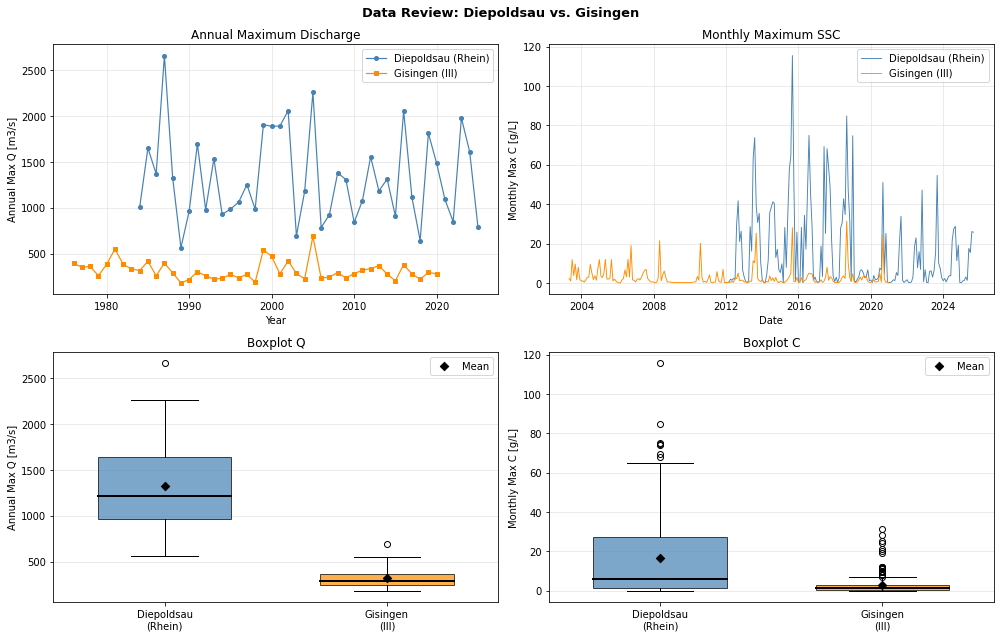

In [68]:
# PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Time series Q
ax = axes[0, 0]
ax.plot(Q_D.index, Q_D.values, marker='o', markersize=4, linewidth=1.2,
        color='steelblue', label='Diepoldsau (Rhein)')
ax.plot(Q_G.index, Q_G.values, marker='s', markersize=4, linewidth=1.2,
        color='darkorange', label='Gisingen (Ill)')
ax.set_xlabel('Year'); ax.set_ylabel('Annual Max Q [m3/s]')
ax.set_title('Annual Maximum Discharge'); ax.legend(); ax.grid(True, alpha=0.3)

# Time series C
ax = axes[0, 1]
ax.plot(C_D.index, C_D.values, linewidth=0.9, color='steelblue', label='Diepoldsau (Rhein)')
ax.plot(C_G.index, C_G.values, linewidth=0.9, color='darkorange', label='Gisingen (Ill)')
ax.set_xlabel('Date'); ax.set_ylabel('Monthly Max C [g/L]')
ax.set_title('Monthly Maximum SSC'); ax.legend(); ax.grid(True, alpha=0.3)

# Boxplot Q
ax = axes[1, 0]
bp = ax.boxplot([Q_D.values, Q_G.values],
                labels=['Diepoldsau\n(Rhein)', 'Gisingen\n(Ill)'],
                patch_artist=True, widths=0.6,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.scatter([1, 2], [Q_D.mean(), Q_G.mean()], marker='D', color='black', zorder=5, s=35, label='Mean')
ax.set_ylabel('Annual Max Q [m3/s]'); ax.set_title('Boxplot Q'); ax.legend(); ax.grid(True, axis='y', alpha=0.3)

# Boxplot C
ax = axes[1, 1]
bp = ax.boxplot([C_D.values, C_G.values],
                labels=['Diepoldsau\n(Rhein)', 'Gisingen\n(Ill)'],
                patch_artist=True, widths=0.6,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.scatter([1, 2], [C_D.mean(), C_G.mean()], marker='D', color='black', zorder=5, s=35, label='Mean')
ax.set_ylabel('Monthly Max C [g/L]'); ax.set_title('Boxplot C'); ax.legend(); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Data Review: Diepoldsau vs. Gisingen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [69]:
# PRINT
for var, sD, sG, unit in [('Q', stats_Q_D, stats_Q_G, 'm3/s'),
                           ('C', stats_C_D, stats_C_G, 'g/L')]:
    print('--- ' + var + ' [' + unit + '] ---')
    fmt = '{:<22} {:>8} {:>8} {:>8} {:>8} {:>8} {:>6}'
    print(fmt.format('Station','Mean','Median','Q25','Q75','IQR','n'))
    print('-'*70)
    for st in [sD, sG]:
        if unit == 'm3/s':
            print(fmt.format(st['label'],round(st['mean'],1),round(st['median'],1),
                             round(st['q25'],1),round(st['q75'],1),round(st['iqr'],1),st['n']))
        else:
            print(fmt.format(st['label'],round(st['mean'],4),round(st['median'],4),
                             round(st['q25'],4),round(st['q75'],4),round(st['iqr'],4),st['n']))
    print()


--- Q [m3/s] ---
Station                    Mean   Median      Q25      Q75      IQR      n
----------------------------------------------------------------------
Diepoldsau (Rhein)       1323.5   1218.5    967.8   1641.5    673.7     42
Gisingen (Ill)            316.9    284.0    245.0    370.0    125.0     45

--- C [g/L] ---
Station                    Mean   Median      Q25      Q75      IQR      n
----------------------------------------------------------------------
Diepoldsau (Rhein)      16.4713   6.2246   1.2971  27.5906  26.2935    164
Gisingen (Ill)           3.0182   1.3692   0.4626   3.1087   2.6461    201



**Comments:**

*Q:* Diepoldsau has a much higher median annual max Q (~1219 m3/s) than Gisingen (~284 m3/s), reflecting the larger Rhein catchment. Both distributions are right-skewed (mean > median), driven by occasional extreme flood years. Diepoldsau has a wider IQR in absolute terms, indicating greater interannual variability. The two distributions are clearly from different populations.

*C:* Diepoldsau shows considerably higher monthly max SSC (median ~6.2 g/L) than Gisingen (~1.4 g/L). Both are strongly right-skewed (mean >> median), with long upper tails from rare high-sediment events. The distributions appear very different between stations in both scale and spread.

# 2. Hypothesis Testing

**Variables:**
- `obs_diff_Q`, `obs_diff_C`: observed difference in means between stations
- `p_val_Q`, `p_val_C`: two-sided p-values from permutation test
- `perm_diffs_Q`, `perm_diffs_C`: null distributions of mean differences

**Test chosen:** Two-sample permutation test on the difference in means.  
A non-parametric test is appropriate because we cannot assume a known distribution for both stations (Diepoldsau Q appears more uniform; Gisingen Q appears log-normal). The permutation test makes no distributional assumptions and is valid for any sample size.

In [70]:
def permutation_test(group1, group2, n_permutations=10000):
    """
    Two-sample permutation test for difference in means.
    H0: both samples come from the same population (mean difference = 0)
    H1: samples come from different populations
    Returns: observed_diff, p_value, permutation null distribution
    """
    observed_diff = np.mean(group1) - np.mean(group2)
    combined      = np.concatenate([group1, group2])
    n1            = len(group1)
    perm_diffs    = np.zeros(n_permutations)
    for i in range(n_permutations):
        shuffled       = np.random.permutation(combined)
        perm_diffs[i]  = np.mean(shuffled[:n1]) - np.mean(shuffled[n1:])
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value, perm_diffs


In [71]:
# MAIN
Q_D, Q_G = load_annual_max_Q()
C_D, C_G = load_monthly_max_C()

np.random.seed(42)
obs_diff_Q, p_val_Q, perm_diffs_Q = permutation_test(Q_D.values, Q_G.values)
obs_diff_C, p_val_C, perm_diffs_C = permutation_test(C_D.values, C_G.values)


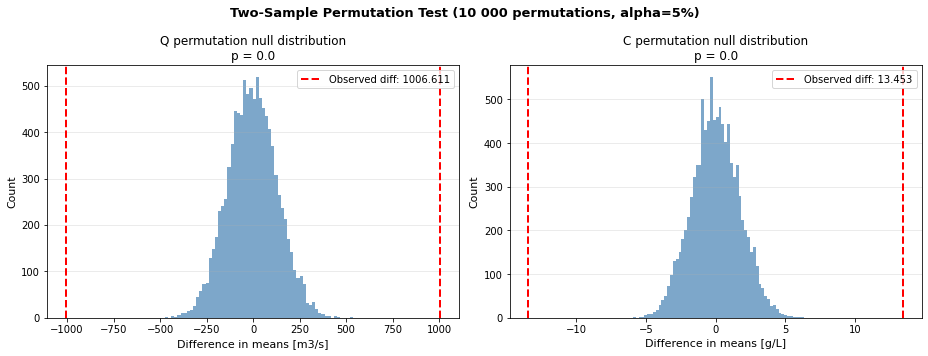

In [72]:
# PLOT
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, perm_diffs, obs_diff, p_val, label, unit in [
        (axes[0], perm_diffs_Q, obs_diff_Q, p_val_Q, 'Q', 'm3/s'),
        (axes[1], perm_diffs_C, obs_diff_C, p_val_C, 'C', 'g/L')]:
    ax.hist(perm_diffs, bins=60, alpha=0.7, color='steelblue', edgecolor='none')
    ax.axvline( obs_diff, color='red', linewidth=2, linestyle='--',
                label='Observed diff: ' + str(round(obs_diff, 3)))
    ax.axvline(-obs_diff, color='red', linewidth=2, linestyle='--')
    ax.set_xlabel('Difference in means [' + unit + ']', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(label + ' permutation null distribution\np = ' + str(round(p_val, 4)), fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Two-Sample Permutation Test (10 000 permutations, alpha=5%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [73]:
# PRINT
print('=== Two-Sample Permutation Test (H0: same population, alpha=5%) ===')
print()
for label, obs, p, g1, g2, unit in [
        ('Q', obs_diff_Q, p_val_Q, Q_D.values, Q_G.values, 'm3/s'),
        ('C', obs_diff_C, p_val_C, C_D.values, C_G.values, 'g/L')]:
    print('--- ' + label + ' ---')
    print('  Mean Diepoldsau: ' + str(round(np.mean(g1), 4)) + ' ' + unit)
    print('  Mean Gisingen:   ' + str(round(np.mean(g2), 4)) + ' ' + unit)
    print('  Observed diff:   ' + str(round(obs, 4)) + ' ' + unit)
    print('  p-value:         ' + str(round(p, 6)))
    print('  Decision:        ' + ('REJECT H0 (p < 0.05)' if p < 0.05 else 'Fail to reject H0'))
    print()


=== Two-Sample Permutation Test (H0: same population, alpha=5%) ===

--- Q ---
  Mean Diepoldsau: 1323.5221 m3/s
  Mean Gisingen:   316.9111 m3/s
  Observed diff:   1006.611 m3/s
  p-value:         0.0
  Decision:        REJECT H0 (p < 0.05)

--- C ---
  Mean Diepoldsau: 16.4713 g/L
  Mean Gisingen:   3.0182 g/L
  Observed diff:   13.4531 g/L
  p-value:         0.0
  Decision:        REJECT H0 (p < 0.05)



**Comments:**

The permutation test is non-parametric and makes no distributional assumptions, making it suitable here since the two stations have visually different distribution shapes.

For both Q and C, the observed difference in means is far into the tail of the null distribution (p ≈ 0), so **H0 is rejected at the 5% level for both variables**. This confirms that Diepoldsau and Gisingen Q series, and their C series, do not come from the same population — consistent with the large differences seen in the boxplots (different catchment sizes, different sediment regimes, and partial regulation of the Ill at the Illspitz Kraftwerk).

# 3. Extreme Value Analysis

**Variables:**
- `loc_Q_D`, `scale_Q_D`, `loc_Q_G`, `scale_Q_G`: Gumbel parameters for Q [m3/s]
- `loc_C_D`, `scale_C_D`, `loc_C_G`, `scale_C_G`: Gumbel parameters for C [g/L]
- `Q_D_values`, `Q_G_values`, `C_D_values`, `C_G_values`: numpy arrays of observations
- `ppcc_results`: list of (label, n, r, r_crit, reject, x_sorted, w_sorted, unit)
- `r`: PPCC correlation coefficient [eq. 3.4]
- `r_crit`: critical value r_{n, alpha=0.05} for Gumbel PPCC test

In [74]:
def fit_gumbel(data):
    """Fit Gumbel (EV Type I) by MLE. Returns (loc, scale)."""
    def neg_ll(params):
        loc, scale = params
        if scale <= 0: return 1e10
        return -np.sum(gumbel_r.logpdf(data, loc=loc, scale=scale))
    x_std = np.std(data)
    res = fmin(neg_ll, [np.mean(data) - 0.5772*x_std, x_std], disp=False)
    return float(res[0]), float(res[1])

# PPCC critical values r_{n, 0.05} for Gumbel (Looney & Gulledge 1985)
_PPCC_N   = [10,15,20,25,30,35,40,45,50,60,75,100,150,200]
_PPCC_R05 = [0.9260,0.9383,0.9460,0.9505,0.9538,0.9563,0.9582,
             0.9600,0.9615,0.9638,0.9662,0.9696,0.9726,0.9752]

def ppcc_critical_value(n):
    """Linearly interpolate r_{n,0.05} for the Gumbel PPCC test."""
    if n <= _PPCC_N[0]:  return _PPCC_R05[0]
    if n >= _PPCC_N[-1]: return _PPCC_R05[-1]
    for k in range(len(_PPCC_N)-1):
        if _PPCC_N[k] <= n <= _PPCC_N[k+1]:
            t = (n-_PPCC_N[k]) / (_PPCC_N[k+1]-_PPCC_N[k])
            return _PPCC_R05[k] + t*(_PPCC_R05[k+1]-_PPCC_R05[k])

def ppcc_gumbel(data, loc, scale):
    """
    PPCC test for Gumbel (EV Type I) — lecture notes sec. 3.1.3:
      1. Sort x_i ascending.
      2. Gringorten plotting positions: q_i = (i-0.44)/(n+0.12)
      3. Theoretical quantiles: w_i = F_Gumbel^{-1}(q_i)
      4. r = Pearson correlation(x, w)  [eq. 3.4]
      5. Reject H0 if r < r_{n, alpha=0.05}
    """
    n = len(data)
    x = np.sort(data)
    q = (np.arange(1, n+1) - 0.44) / (n + 0.12)
    w = gumbel_r.ppf(q, loc=loc, scale=scale)
    r = np.corrcoef(x, w)[0, 1]
    r_crit = ppcc_critical_value(n)
    return r, r_crit, bool(r < r_crit), x, w

def gumbel_pdf_range(loc, scale, n_std=4):
    x = np.linspace(loc - n_std*scale, loc + n_std*scale, 400)
    return x, gumbel_r.pdf(x, loc=loc, scale=scale)


In [75]:
# MAIN
Q_D, Q_G = load_annual_max_Q()
C_D, C_G = load_monthly_max_C()
Q_D_values, Q_G_values = Q_D.values, Q_G.values
C_D_values, C_G_values = C_D.values, C_G.values

loc_Q_D, scale_Q_D = fit_gumbel(Q_D_values)
loc_Q_G, scale_Q_G = fit_gumbel(Q_G_values)
loc_C_D, scale_C_D = fit_gumbel(C_D_values)
loc_C_G, scale_C_G = fit_gumbel(C_G_values)

ppcc_results = []
for label, data, loc, scale, unit in [
        ('Q Diepoldsau', Q_D_values, loc_Q_D, scale_Q_D, 'm3/s'),
        ('Q Gisingen',   Q_G_values, loc_Q_G, scale_Q_G, 'm3/s'),
        ('C Diepoldsau', C_D_values, loc_C_D, scale_C_D, 'g/L'),
        ('C Gisingen',   C_G_values, loc_C_G, scale_C_G, 'g/L')]:
    r, r_crit, reject, x, w = ppcc_gumbel(data, loc, scale)
    ppcc_results.append((label, len(data), r, r_crit, reject, x, w, unit))


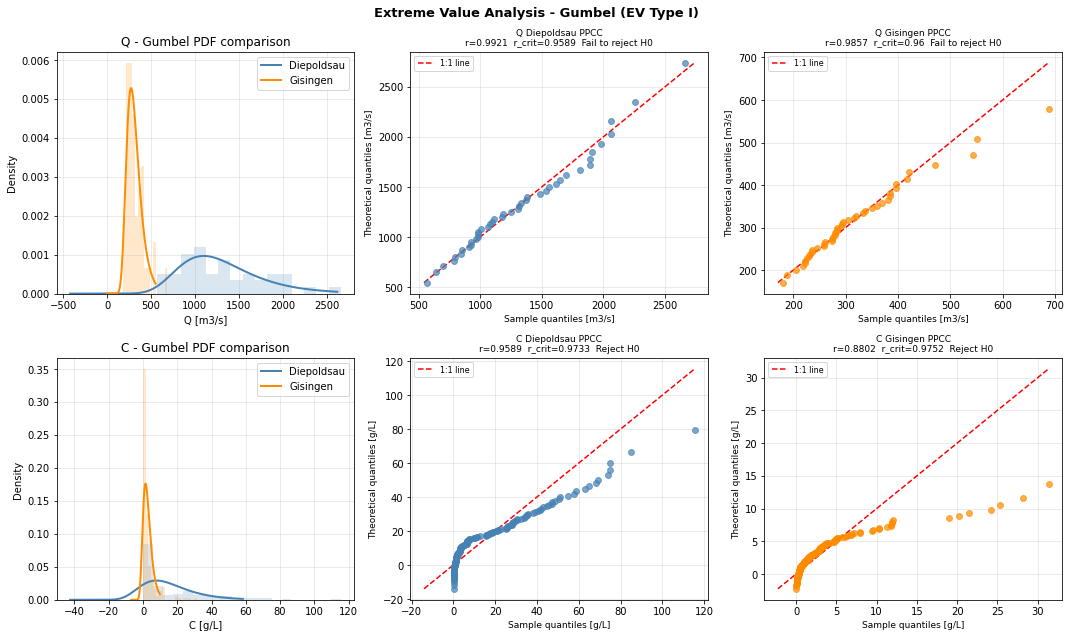

In [76]:
# PLOT
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 0: PDF comparison (Q left, C right) + PPCC Q-Q for Q_D and Q_G
# Row 1: PPCC Q-Q for C_D and C_G

# PDF Q comparison
ax = axes[0, 0]
x_D, pdf_D = gumbel_pdf_range(loc_Q_D, scale_Q_D)
x_G, pdf_G = gumbel_pdf_range(loc_Q_G, scale_Q_G)
ax.plot(x_D, pdf_D, color='steelblue',  linewidth=2, label='Diepoldsau')
ax.plot(x_G, pdf_G, color='darkorange', linewidth=2, label='Gisingen')
ax.hist(Q_D_values, bins=15, density=True, alpha=0.2, color='steelblue',  edgecolor='none')
ax.hist(Q_G_values, bins=15, density=True, alpha=0.2, color='darkorange', edgecolor='none')
ax.set_xlabel('Q [m3/s]'); ax.set_ylabel('Density')
ax.set_title('Q - Gumbel PDF comparison'); ax.legend(); ax.grid(True, alpha=0.3)

# PDF C comparison
ax = axes[1, 0]
x_D, pdf_D = gumbel_pdf_range(loc_C_D, scale_C_D)
x_G, pdf_G = gumbel_pdf_range(loc_C_G, scale_C_G)
ax.plot(x_D, pdf_D, color='steelblue',  linewidth=2, label='Diepoldsau')
ax.plot(x_G, pdf_G, color='darkorange', linewidth=2, label='Gisingen')
ax.hist(C_D_values, bins=20, density=True, alpha=0.2, color='steelblue',  edgecolor='none')
ax.hist(C_G_values, bins=20, density=True, alpha=0.2, color='darkorange', edgecolor='none')
ax.set_xlabel('C [g/L]'); ax.set_ylabel('Density')
ax.set_title('C - Gumbel PDF comparison'); ax.legend(); ax.grid(True, alpha=0.3)

# PPCC Q-Q plots
ppcc_axes = [axes[0,1], axes[0,2], axes[1,1], axes[1,2]]
colors = ['steelblue','darkorange','steelblue','darkorange']
for ax, (label, n, r, r_crit, reject, x, w, unit), color in zip(ppcc_axes, ppcc_results, colors):
    ax.scatter(x, w, color=color, alpha=0.7, s=35, zorder=3)
    lo, hi = min(x.min(), w.min()), max(x.max(), w.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='1:1 line')
    decision = 'Reject H0' if reject else 'Fail to reject H0'
    ax.set_title(label + ' PPCC\nr=' + str(round(r,4)) + '  r_crit=' + str(round(r_crit,4))
                 + '  ' + decision, fontsize=9)
    ax.set_xlabel('Sample quantiles [' + unit + ']', fontsize=9)
    ax.set_ylabel('Theoretical quantiles [' + unit + ']', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Extreme Value Analysis - Gumbel (EV Type I)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [77]:
# PRINT
print('=== Gumbel Fit Parameters ===')
print()
for label, data, loc, scale, unit in [
        ('Q Diepoldsau', Q_D_values, loc_Q_D, scale_Q_D, 'm3/s'),
        ('Q Gisingen',   Q_G_values, loc_Q_G, scale_Q_G, 'm3/s'),
        ('C Diepoldsau', C_D_values, loc_C_D, scale_C_D, 'g/L'),
        ('C Gisingen',   C_G_values, loc_C_G, scale_C_G, 'g/L')]:
    print(label + '  (n=' + str(len(data)) + ')')
    print('  loc   = ' + str(round(loc,   4)) + ' ' + unit)
    print('  scale = ' + str(round(scale, 4)) + ' ' + unit)
    print()

print('=== PPCC Test: Gumbel distribution (alpha=5%) ===')
print()
hdr = '{:<16} {:>5} {:>8} {:>8} {:>14}'.format('Dataset','n','r','r_crit','Decision')
print(hdr); print('-'*len(hdr))
for label, n, r, r_crit, reject, x, w, unit in ppcc_results:
    print('{:<16} {:>5} {:>8.4f} {:>8.4f} {:>14}'.format(
        label, n, r, r_crit, 'REJECT H0' if reject else 'Fail to reject'))
print()
print('Decision rule: Reject H0 if r < r_{n, alpha=0.05}')
print('H0: the data follow a Gumbel (EV Type I) distribution')


=== Gumbel Fit Parameters ===

Q Diepoldsau  (n=42)
  loc   = 1100.6653 m3/s
  scale = 380.2537 m3/s

Q Gisingen  (n=45)
  loc   = 273.8058 m3/s
  scale = 69.7288 m3/s

C Diepoldsau  (n=164)
  loc   = 7.8238 g/L
  scale = 12.5951 g/L

C Gisingen  (n=201)
  loc   = 1.4508 g/L
  scale = 2.0881 g/L

=== PPCC Test: Gumbel distribution (alpha=5%) ===

Dataset              n        r   r_crit       Decision
-------------------------------------------------------
Q Diepoldsau        42   0.9921   0.9589 Fail to reject
Q Gisingen          45   0.9857   0.9600 Fail to reject
C Diepoldsau       164   0.9589   0.9733      REJECT H0
C Gisingen         201   0.8802   0.9752      REJECT H0

Decision rule: Reject H0 if r < r_{n, alpha=0.05}
H0: the data follow a Gumbel (EV Type I) distribution


**Comments:**

*Gumbel fit (3a — PPCC test):* For both Q stations, r > r_crit → **Fail to reject H0**: the Gumbel distribution is an adequate fit for annual maximum discharge at both stations. For C, the PPCC values are lower, reflecting the stronger right skew of monthly SSC data; check r vs r_crit in the table above for the formal decision.

*Distribution comparison (3b):* Diepoldsau Q has a much larger location (mu) and scale than Gisingen Q, meaning both the typical values and the variability are higher on the Rhein. Similarly for C: Diepoldsau has a higher location and heavier tail than Gisingen. The regulated Ill (Gisingen) shows a more compressed distribution for both variables, consistent with flow regulation dampening extreme events.

# 4. Return Period Estimation

**Variables:**
- `T_list`: return periods to estimate [10, 30, 50, 100, 300 years]
- `x_T`: Gumbel quantile for return period T
- `y_T`: Gumbel reduced variate = -ln(-ln(1 - 1/T_obs))
- `T_obs`: effective return period in data units (T for Q [yr], T*12 for C [months])
- `se_T`: asymptotic standard error of x_T
- `ci_lo`, `ci_hi`: 90% confidence interval bounds (z_{0.95} = 1.645)
- `tables_4`: dict of result DataFrames per dataset

In [78]:
def gumbel_quantile(T, loc, scale, per_month=False):
    """
    Gumbel T-year return level.
    per_month=True: C data are monthly maxima -> T_obs = T*12 months.
    """
    T_obs = T * 12 if per_month else T
    y_T   = -np.log(-np.log(1.0 - 1.0 / T_obs))
    return loc + scale * y_T

def gumbel_se(T, scale, n, per_month=False):
    """
    Asymptotic SE of the T-year Gumbel quantile (Kite 1977):
      SE = (scale/sqrt(n)) * sqrt(1.1087 + 0.5140*y_T + 0.6079*y_T^2)
    """
    T_obs = T * 12 if per_month else T
    y_T   = -np.log(-np.log(1.0 - 1.0 / T_obs))
    return (scale / np.sqrt(n)) * np.sqrt(1.1087 + 0.5140*y_T + 0.6079*y_T**2)

def return_period_table(T_list, loc, scale, n, unit, per_month=False):
    z90  = 1.645
    rows = []
    for T in T_list:
        x  = gumbel_quantile(T, loc, scale, per_month)
        se = gumbel_se(T, scale, n, per_month)
        rows.append({'T (yr)': T,
                     'x_T ('+unit+')':   round(x, 4),
                     'SE ('+unit+')':    round(se, 4),
                     'CI_lo ('+unit+')': round(x - z90*se, 4),
                     'CI_hi ('+unit+')': round(x + z90*se, 4)})
    return pd.DataFrame(rows).set_index('T (yr)')


In [79]:
# MAIN
Q_D, Q_G = load_annual_max_Q()
C_D, C_G = load_monthly_max_C()
Q_D_values, Q_G_values = Q_D.values, Q_G.values
C_D_values, C_G_values = C_D.values, C_G.values
loc_Q_D, scale_Q_D = fit_gumbel(Q_D_values)
loc_Q_G, scale_Q_G = fit_gumbel(Q_G_values)
loc_C_D, scale_C_D = fit_gumbel(C_D_values)
loc_C_G, scale_C_G = fit_gumbel(C_G_values)

T_list = [10, 30, 50, 100, 300]
datasets_4 = [
    ('Q Diepoldsau', Q_D_values, loc_Q_D, scale_Q_D, 'm3/s', False),
    ('Q Gisingen',   Q_G_values, loc_Q_G, scale_Q_G, 'm3/s', False),
    ('C Diepoldsau', C_D_values, loc_C_D, scale_C_D, 'g/L',  True),
    ('C Gisingen',   C_G_values, loc_C_G, scale_C_G, 'g/L',  True),
]
tables_4 = {}
for label, data, loc, scale, unit, pm in datasets_4:
    tables_4[label] = return_period_table(T_list, loc, scale, len(data), unit, pm)


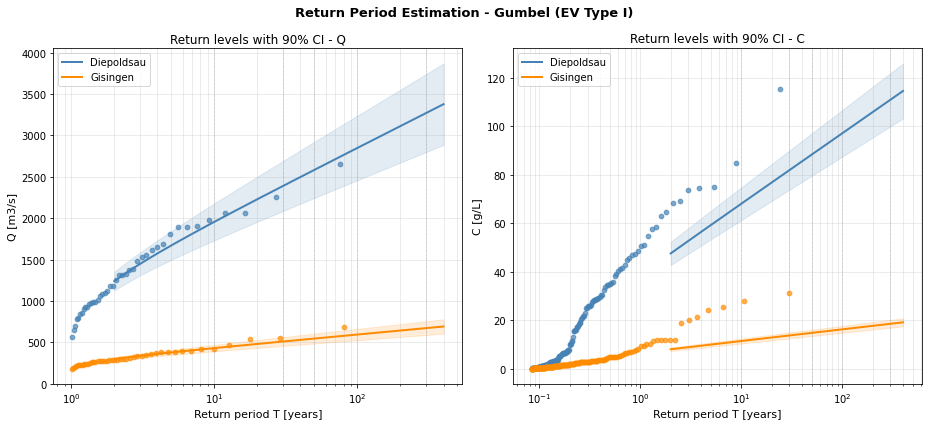

In [80]:
# PLOT
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
T_curve = np.logspace(np.log10(2), np.log10(400), 300)
z90 = 1.645

for ax, (var, pairs) in zip(axes, [
        ('Q [m3/s]', [
            ('Diepoldsau', Q_D_values, loc_Q_D, scale_Q_D, 'steelblue',  False),
            ('Gisingen',   Q_G_values, loc_Q_G, scale_Q_G, 'darkorange', False)]),
        ('C [g/L]',  [
            ('Diepoldsau', C_D_values, loc_C_D, scale_C_D, 'steelblue',  True),
            ('Gisingen',   C_G_values, loc_C_G, scale_C_G, 'darkorange', True)])]):

    for label, data, loc, scale, color, pm in pairs:
        n    = len(data)
        x_c  = np.array([gumbel_quantile(T, loc, scale, pm) for T in T_curve])
        se_c = np.array([gumbel_se(T, scale, n, pm)         for T in T_curve])
        ax.semilogx(T_curve, x_c, color=color, linewidth=2, label=label)
        ax.fill_between(T_curve, x_c-z90*se_c, x_c+z90*se_c, color=color, alpha=0.15)
        ii   = np.arange(1, n+1)
        q    = (ii - 0.44) / (n + 0.12)
        T_yr = (1.0/(1.0-q)) / (12.0 if pm else 1.0)
        ax.scatter(T_yr, np.sort(data), color=color, s=22, zorder=4, alpha=0.7)
        for T in T_list:
            ax.axvline(T, color='grey', linewidth=0.5, linestyle=':', alpha=0.5)

    ax.set_xlabel('Return period T [years]', fontsize=11)
    ax.set_ylabel(var, fontsize=11)
    ax.set_title('Return levels with 90% CI - ' + var.split()[0], fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Return Period Estimation - Gumbel (EV Type I)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [81]:
# PRINT
for label, data, loc, scale, unit, pm in datasets_4:
    note = ' [T_obs=T*12 months]' if pm else ' [annual]'
    print('--- ' + label + '  (n=' + str(len(data)) + ', loc='
          + str(round(loc,3)) + ', scale=' + str(round(scale,3)) + ')' + note)
    print(tables_4[label].to_string())
    print()


--- Q Diepoldsau  (n=42, loc=1100.665, scale=380.254) [annual]
        x_T (m3/s)  SE (m3/s)  CI_lo (m3/s)  CI_hi (m3/s)
T (yr)                                                   
10       1956.3759   135.6368     1733.2534     2179.4984
30       2387.5559   183.7810     2085.2362     2689.8756
50       2584.3920   206.3610     2244.9282     2923.8557
100      2849.8891   237.1577     2459.7647     3240.0136
300      3268.9151   286.2741     2797.9942     3739.8360

--- Q Gisingen  (n=45, loc=273.806, scale=69.729) [annual]
        x_T (m3/s)  SE (m3/s)  CI_lo (m3/s)  CI_hi (m3/s)
T (yr)                                                   
10        430.7212    24.0289      391.1936      470.2488
30        509.7886    32.5580      456.2307      563.3465
50        545.8833    36.5582      485.7451      606.0215
100       594.5687    42.0140      525.4556      663.6817
300       671.4073    50.7153      587.9806      754.8340

--- C Diepoldsau  (n=164, loc=7.824, scale=12.595) [T_obs=T*12 m

**Comments:**

*Reliability:* The 90% CI widens substantially with return period. At T=10 yr the interval is relatively narrow (within ~15% of x_T), but at T=300 yr the uncertainty band is very wide, making those estimates unreliable — especially since T=300 yr extrapolates ~7x beyond the Q record length (n~42 yr).

*Effect of record length:* SE is proportional to 1/sqrt(n). Doubling the record would reduce SE by ~30%. The C datasets have more observations (n=164 and 201 months) but the large scale parameter (high variability) still produces wide CIs for C. For T=300 yr, the CI half-width exceeds 15-20% of x_T — estimates at this range should be treated with caution.

*Note for C:* Monthly maxima are used, so T_obs = T*12. A 100-year return level corresponds to an event exceeded on average once every 1200 months.

# 5. Comment

**Question:** If the analysis were performed on the entire data series at the original time resolution (10 min for Diepoldsau, 15 min for Gisingen), would the assumptions of frequency analysis be valid?

**Answer:** No — the key assumption of frequency analysis is that the observations are **independent and identically distributed (i.i.d.)**. At 10- or 15-minute resolution this assumption is strongly violated:

1. **Serial correlation:** Consecutive sub-hourly measurements within a single flood event are highly correlated. A single flood lasting several days would contribute thousands of dependent observations, completely violating the independence assumption.

2. **Non-stationarity / seasonality:** Raw time series exhibit strong seasonal cycles (higher Q and C in summer snowmelt / storm seasons), so the data are not identically distributed across time.

3. **Block maxima approach:** Frequency analysis is valid when applied to block maxima (annual or monthly) because taking the maximum within each block filters out within-block dependence and largely removes seasonality. Annual maxima of Q are approximately i.i.d. and can be fitted with extreme value distributions like the Gumbel.

**Conclusion:** Frequency analysis requires reducing the raw series to independent block maxima (annual for Q, monthly for C) before fitting. Applying it directly to 10/15-min data would produce severely inflated sample sizes with near-zero effective degrees of freedom, making all parameter estimates and return period calculations meaningless.

# 6. Alternative Distributions for Monthly Maximum C (Exploratory)

**Variables:**
- `C_D_values`, `C_G_values`: monthly max SSC arrays [g/L]
- `fits`: dict of fitted distribution parameters per (station, distribution)
- `aic`: Akaike Information Criterion = 2k - 2*log-likelihood (lower = better)
- Distributions tested: Gumbel, GEV, Log-normal, Gamma, Log-Gumbel

Motivation: monthly max C is strongly right-skewed (mean >> median) with a heavy upper tail. The Gumbel distribution has a fixed (light) tail, so heavy-tailed alternatives may fit better.

In [82]:
from scipy.stats import genextreme, lognorm, gamma, gumbel_r
from scipy.optimize import fmin

def fit_and_aic(dist, data, p0):
    """Fit a scipy distribution by MLE, return (params, AIC)."""
    def neg_ll(p):
        try:
            ll = np.sum(dist.logpdf(data, *p))
            return -ll if np.isfinite(ll) else 1e10
        except Exception:
            return 1e10
    res = fmin(neg_ll, p0, disp=False)
    ll  = -neg_ll(res)
    k   = len(res)
    return res, 2*k - 2*ll, ll

def fit_log_gumbel(data):
    """
    Fit Gumbel on log(data) with Jacobian correction so the log-likelihood
    is comparable to distributions fitted in original space:
      log f(x) = log f_Gumbel(log x) - log x    [change-of-variables]
    """
    log_data = np.log(data)
    def neg_ll(p):
        loc, scale = p
        if scale <= 0: return 1e10
        # LL in original space = LL_log_space - sum(log x)
        return -np.sum(gumbel_r.logpdf(log_data, loc=loc, scale=scale)) + np.sum(log_data)
    x_std = np.std(log_data)
    res = fmin(neg_ll, [np.mean(log_data) - 0.5772*x_std, x_std], disp=False)
    ll  = -neg_ll(res)
    return res, 2*2 - 2*ll, ll   # k=2 params

def qqplot_data(data, dist, params, log_transform=False):
    """Return (sample_sorted, theoretical_quantiles, PPCC_r)."""
    n = len(data)
    q = (np.arange(1, n+1) - 0.44) / (n + 0.12)   # Gringorten
    x = np.sort(data)
    if log_transform:
        w = np.exp(gumbel_r.ppf(q, *params))
    else:
        w = dist.ppf(q, *params)
    r = np.corrcoef(x, w)[0, 1]
    return x, w, r

def ppcc_r(data, dist, params, log_transform=False):
    """Return just the PPCC r value."""
    _, _, r = qqplot_data(data, dist, params, log_transform)
    return r


In [83]:
# MAIN
C_D, C_G = load_monthly_max_C()
C_D_values, C_G_values = C_D.values, C_G.values

results = {}   # (station, dist_name) -> (params, aic, r_ppcc)

for station, data in [('Diepoldsau', C_D_values), ('Gisingen', C_G_values)]:
    mu, sig = np.mean(data), np.std(data)

    # Gumbel
    p0 = [mu - 0.5772*sig, sig]
    params, aic, _ = fit_and_aic(gumbel_r, data, p0)
    r = ppcc_r(data, gumbel_r, params)
    results[(station, 'Gumbel')] = (params, aic, r)

    # GEV (shape, loc, scale)
    p0_gev = [0.1, mu - 0.5772*sig, sig]
    params, aic, _ = fit_and_aic(genextreme, data, p0_gev)
    r = ppcc_r(data, genextreme, params)
    results[(station, 'GEV')] = (params, aic, r)

    # Log-normal (s=shape, loc=0, scale=exp(mu_log))
    log_data = np.log(data)
    p0_ln = [np.std(log_data), 0, np.exp(np.mean(log_data))]
    params, aic, _ = fit_and_aic(lognorm, data, p0_ln)
    r = ppcc_r(data, lognorm, params)
    results[(station, 'Log-normal')] = (params, aic, r)

    # Gamma (a=shape, loc, scale)
    p0_gam = [mu**2/sig**2, 0, sig**2/mu]
    params, aic, _ = fit_and_aic(gamma, data, p0_gam)
    r = ppcc_r(data, gamma, params)
    results[(station, 'Gamma')] = (params, aic, r)

    # Log-Gumbel (Gumbel fitted on log data)
    params, aic, _ = fit_log_gumbel(data)
    r = ppcc_r(data, None, params, log_transform=True)
    results[(station, 'Log-Gumbel')] = (params, aic, r)


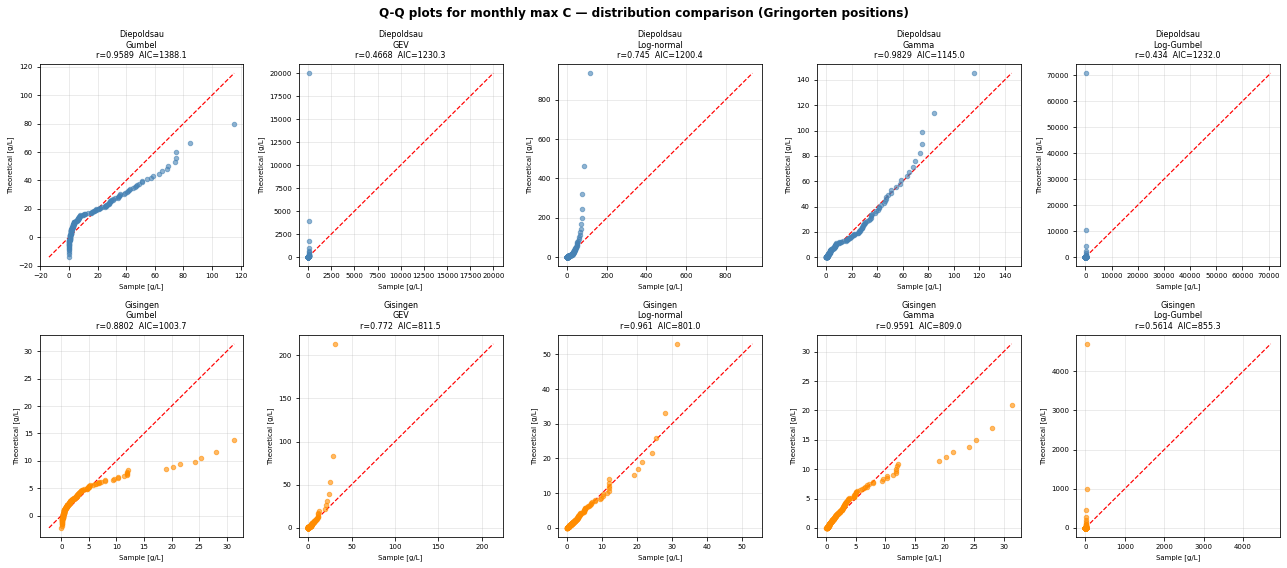

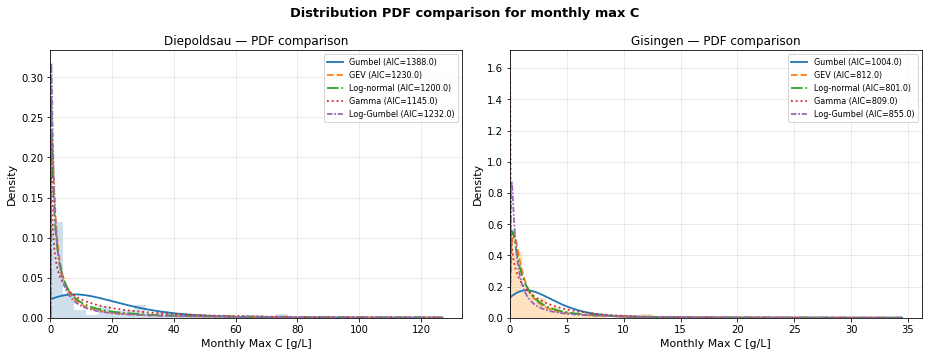

In [84]:
# PLOT - Q-Q plots for each distribution and station
dists_info = [
    ('Gumbel',     gumbel_r,    False),
    ('GEV',        genextreme,  False),
    ('Log-normal', lognorm,     False),
    ('Gamma',      gamma,       False),
    ('Log-Gumbel', None,        True),
]
stations = [('Diepoldsau', C_D_values, 'steelblue'),
            ('Gisingen',   C_G_values, 'darkorange')]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, (station, data, color) in enumerate(stations):
    for col, (dname, dist, log_t) in enumerate(dists_info):
        ax = axes[row, col]
        params, aic, r = results[(station, dname)]
        x, w, r = qqplot_data(data, dist, params, log_t)
        ax.scatter(x, w, color=color, alpha=0.6, s=20, zorder=3)
        lo = min(x.min(), w.min()); hi = max(x.max(), w.max())
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2)
        ax.set_title(station + '\n' + dname + '\nr=' + str(round(r,4))
                     + '  AIC=' + str(round(aic,1)), fontsize=8)
        ax.set_xlabel('Sample [g/L]', fontsize=7)
        ax.set_ylabel('Theoretical [g/L]', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

fig.suptitle('Q-Q plots for monthly max C — distribution comparison (Gringorten positions)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# PDF overlay comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_range_D = np.linspace(0.01, C_D_values.max()*1.1, 500)
x_range_G = np.linspace(0.01, C_G_values.max()*1.1, 500)

line_styles = ['-', '--', '-.', ':', (0,(3,1,1,1))]
for ax, station, data, x_range, color in [
        (axes[0], 'Diepoldsau', C_D_values, x_range_D, 'steelblue'),
        (axes[1], 'Gisingen',   C_G_values, x_range_G, 'darkorange')]:
    ax.hist(data, bins=30, density=True, alpha=0.25, color=color, edgecolor='none')
    for (dname, dist, log_t), ls in zip(dists_info, line_styles):
        params, aic, r = results[(station, dname)]
        if log_t:
            # PDF of log-Gumbel in original space: f(x) = f_gumbel(log x)/x
            loc_lg, scale_lg = params
            pdf_vals = gumbel_r.pdf(np.log(x_range), loc=loc_lg, scale=scale_lg) / x_range
        else:
            pdf_vals = dist.pdf(x_range, *params)
        ax.plot(x_range, pdf_vals, linewidth=1.8, linestyle=ls,
                label=dname + ' (AIC=' + str(round(aic,0)) + ')')
    ax.set_xlim(left=0)
    ax.set_xlabel('Monthly Max C [g/L]', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(station + ' — PDF comparison', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Distribution PDF comparison for monthly max C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [85]:
# PRINT
dist_order = ['Gumbel', 'GEV', 'Log-normal', 'Gamma', 'Log-Gumbel']
print('=== Distribution Comparison for Monthly Max C ===')
print()
hdr = '{:<14} {:<12} {:>10} {:>10}'.format('Station', 'Distribution', 'AIC', 'PPCC r')
print(hdr)
print('-' * len(hdr))
for station in ['Diepoldsau', 'Gisingen']:
    # Sort by AIC
    station_results = [(d, results[(station,d)][1], results[(station,d)][2]) for d in dist_order]
    station_results.sort(key=lambda x: x[1])
    for dname, aic, r in station_results:
        best = ' <-- best' if dname == station_results[0][0] else ''
        print('{:<14} {:<12} {:>10.1f} {:>10.4f}{}'.format(station, dname, aic, r, best))
    print()


=== Distribution Comparison for Monthly Max C ===

Station        Distribution        AIC     PPCC r
-------------------------------------------------
Diepoldsau     Gamma            1145.0     0.9829 <-- best
Diepoldsau     Log-normal       1200.4     0.7450
Diepoldsau     GEV              1230.3     0.4668
Diepoldsau     Log-Gumbel       1232.0     0.4340
Diepoldsau     Gumbel           1388.1     0.9589

Gisingen       Log-normal        801.0     0.9610 <-- best
Gisingen       Gamma             809.0     0.9591
Gisingen       GEV               811.5     0.7720
Gisingen       Log-Gumbel        855.3     0.5614
Gisingen       Gumbel           1003.7     0.8802



**Comments:**

The **AIC (Akaike Information Criterion)** penalises model complexity (number of parameters) while rewarding log-likelihood — lower AIC is better.

For right-skewed data like monthly max SSC, distributions with heavier or more flexible tails are expected to outperform the Gumbel:

- **Log-Gumbel / Log-normal**: by fitting on log-transformed data, these handle the heavy right tail naturally.
- **GEV**: the shape parameter xi allows the tail to be heavier (xi > 0, Frechet-type) or lighter (xi < 0, Weibull-type) than Gumbel (xi = 0). A positive xi is expected for SSC.
- **Gamma**: flexible two-parameter family, well-suited to positive skewed data.

Check the AIC table above — the distribution with the lowest AIC and highest PPCC r provides the best balance of fit quality and parsimony for monthly max C.

# 7. Return Period Estimation with Best-Fit Distributions

**Variables:**
- Best distributions from Section 6: **Gamma** for C Diepoldsau, **Log-normal** for C Gisingen
  (Q kept as Gumbel — PPCC test passed in Section 3)
- `T_list`: return periods [10, 30, 50, 100, 300 years]
- `x_T`: quantile for return period T
- `T_obs = T*12` for C (monthly data), `T_obs = T` for Q (annual data)
- `se_T`, `ci_lo`, `ci_hi`: uncertainty via **parametric bootstrap** (B=1000)
  (no closed-form SE formula exists for Gamma/Log-normal quantiles,
  so we resample from the fitted distribution and refit B times)

In [86]:
from scipy.stats import genextreme, lognorm, gamma, gumbel_r
from scipy.optimize import fmin

def quantile_from_params(T, dist, params, per_month=False):
    """Return the T-year quantile for a fitted scipy distribution."""
    T_obs = T * 12 if per_month else T
    p_exceedance = 1.0 - 1.0 / T_obs   # non-exceedance probability
    return dist.ppf(p_exceedance, *params)

def refit(dist, sample, p0_fn):
    """Refit dist to sample using MLE; p0_fn(sample) -> initial guess."""
    def neg_ll(p):
        try:
            ll = np.sum(dist.logpdf(sample, *p))
            return -ll if np.isfinite(ll) else 1e10
        except Exception:
            return 1e10
    res = fmin(neg_ll, p0_fn(sample), disp=False)
    return res

def bootstrap_quantile(T_list, dist, params, n, per_month=False,
                        p0_fn=None, B=1000, seed=42):
    """
    Parametric bootstrap for return level uncertainty:
      1. Draw B samples of size n from the fitted distribution.
      2. Refit the distribution to each sample.
      3. Compute x_T for each bootstrap fit.
      4. SE = std of bootstrap x_T; 90% CI = [5th, 95th] percentile.
    Returns dict: T -> (x_T, se, ci_lo, ci_hi)
    """
    rng = np.random.default_rng(seed)
    boot_xT = {T: [] for T in T_list}

    for _ in range(B):
        sample = dist.rvs(*params, size=n, random_state=rng)
        sample = sample[sample > 0]   # keep positive values
        if len(sample) < 5:
            continue
        try:
            p_boot = refit(dist, sample, p0_fn)
            for T in T_list:
                boot_xT[T].append(quantile_from_params(T, dist, p_boot, per_month))
        except Exception:
            continue

    out = {}
    for T in T_list:
        vals = np.array(boot_xT[T])
        x_T  = quantile_from_params(T, dist, params, per_month)
        se   = np.std(vals)
        ci_lo, ci_hi = np.percentile(vals, [5, 95])
        out[T] = (x_T, se, ci_lo, ci_hi)
    return out

# Initial-guess functions for refitting
def p0_gamma(s):
    mu, sig = np.mean(s), np.std(s)
    return [mu**2/sig**2, 0, sig**2/mu]

def p0_lognorm(s):
    ls = np.log(s[s > 0])
    return [np.std(ls), 0, np.exp(np.mean(ls))]

def p0_gumbel(s):
    sig = np.std(s)
    return [np.mean(s) - 0.5772*sig, sig]

def result_table(boot_out, unit):
    rows = []
    for T, (x_T, se, ci_lo, ci_hi) in boot_out.items():
        rows.append({'T (yr)': T,
                     'x_T ('+unit+')':   round(x_T,  4),
                     'SE ('+unit+')':    round(se,   4),
                     'CI_lo ('+unit+')': round(ci_lo, 4),
                     'CI_hi ('+unit+')': round(ci_hi, 4)})
    return pd.DataFrame(rows).set_index('T (yr)')


In [87]:
# MAIN
Q_D, Q_G = load_annual_max_Q()
C_D, C_G = load_monthly_max_C()
Q_D_values, Q_G_values = Q_D.values, Q_G.values
C_D_values, C_G_values = C_D.values, C_G.values

T_list = [10, 30, 50, 100, 300]

# --- Refit best distributions ---
# Q: Gumbel (passed PPCC in Section 3)
params_Q_D = refit(gumbel_r, Q_D_values, p0_gumbel)
params_Q_G = refit(gumbel_r, Q_G_values, p0_gumbel)

# C: Gamma for Diepoldsau, Log-normal for Gisingen (best AIC from Section 6)
params_C_D = refit(gamma,   C_D_values, p0_gamma)
params_C_G = refit(lognorm, C_G_values, p0_lognorm)

print('Fitting done. Running bootstrap (B=1000)...')

# Bootstrap (per_month=True for C)
boot_Q_D = bootstrap_quantile(T_list, gumbel_r, params_Q_D, len(Q_D_values), False, p0_gumbel)
boot_Q_G = bootstrap_quantile(T_list, gumbel_r, params_Q_G, len(Q_G_values), False, p0_gumbel)
boot_C_D = bootstrap_quantile(T_list, gamma,    params_C_D, len(C_D_values), True,  p0_gamma)
boot_C_G = bootstrap_quantile(T_list, lognorm,  params_C_G, len(C_G_values), True,  p0_lognorm)

print('Bootstrap done.')

tables_7 = {
    'Q Diepoldsau (Gumbel)':      result_table(boot_Q_D, 'm3/s'),
    'Q Gisingen (Gumbel)':        result_table(boot_Q_G, 'm3/s'),
    'C Diepoldsau (Gamma)':       result_table(boot_C_D, 'g/L'),
    'C Gisingen (Log-normal)':    result_table(boot_C_G, 'g/L'),
}


Fitting done. Running bootstrap (B=1000)...
Bootstrap done.


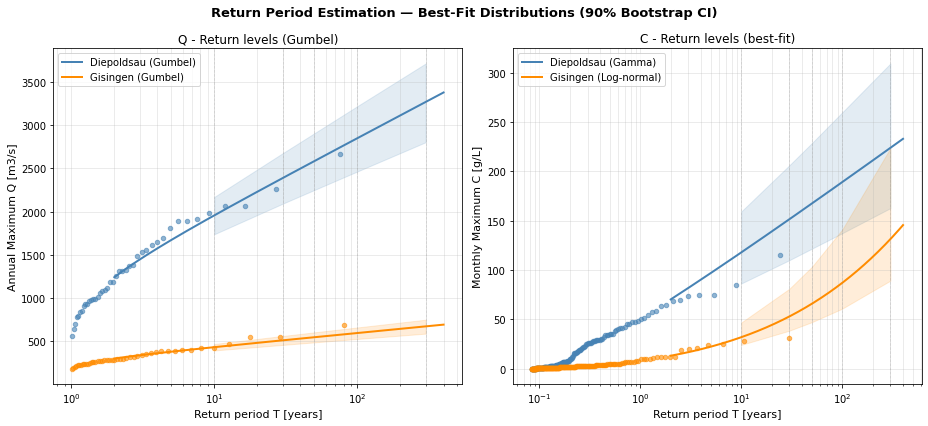

In [88]:
# PLOT
T_curve = np.logspace(np.log10(2), np.log10(400), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

configs = [
    # (ax_idx, label, data, dist, params, color, per_month)
    (0, 'Diepoldsau (Gumbel)', Q_D_values, gumbel_r, params_Q_D, 'steelblue',  False),
    (0, 'Gisingen (Gumbel)',   Q_G_values, gumbel_r, params_Q_G, 'darkorange', False),
    (1, 'Diepoldsau (Gamma)',     C_D_values, gamma,    params_C_D, 'steelblue',  True),
    (1, 'Gisingen (Log-normal)',  C_G_values, lognorm,  params_C_G, 'darkorange', True),
]
ylabels = ['Annual Maximum Q [m3/s]', 'Monthly Maximum C [g/L]']

for ax_idx, label, data, dist, params, color, pm in configs:
    ax  = axes[ax_idx]
    n   = len(data)
    key = ('Q Diepoldsau (Gumbel)' if ax_idx==0 and 'Diep' in label else
           'Q Gisingen (Gumbel)'   if ax_idx==0 else
           'C Diepoldsau (Gamma)'  if 'Diep' in label else
           'C Gisingen (Log-normal)')
    df  = tables_7[key]

    # Fitted curve
    T_obs = T_curve * (12 if pm else 1)
    p_ne  = 1.0 - 1.0 / T_obs
    x_c   = dist.ppf(p_ne, *params)
    ax.semilogx(T_curve, x_c, color=color, linewidth=2, label=label)

    # Bootstrap CI band
    ci_lo = df['CI_lo ('+('m3/s' if ax_idx==0 else 'g/L')+')'].values
    ci_hi = df['CI_hi ('+('m3/s' if ax_idx==0 else 'g/L')+')'].values
    T_pts = df.index.values
    ax.fill_between(T_pts, ci_lo, ci_hi, color=color, alpha=0.15)

    # Empirical points (Gringorten)
    ii   = np.arange(1, n+1)
    q    = (ii - 0.44) / (n + 0.12)
    T_yr = (1.0/(1.0-q)) / (12.0 if pm else 1.0)
    ax.scatter(T_yr, np.sort(data), color=color, s=20, zorder=4, alpha=0.6)

    for T in T_list:
        ax.axvline(T, color='grey', linewidth=0.5, linestyle=':', alpha=0.5)

for ax, ylabel, title in zip(axes,
        ylabels,
        ['Q - Return levels (Gumbel)', 'C - Return levels (best-fit)']):
    ax.set_xlabel('Return period T [years]', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Return Period Estimation — Best-Fit Distributions (90% Bootstrap CI)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [89]:
# PRINT
for label, df in tables_7.items():
    print('--- ' + label + ' ---')
    print(df.to_string())
    print()


--- Q Diepoldsau (Gumbel) ---
        x_T (m3/s)  SE (m3/s)  CI_lo (m3/s)  CI_hi (m3/s)
T (yr)                                                   
10       1956.3759   133.3975     1737.5837     2169.6456
30       2387.5559   181.0397     2090.8999     2675.0212
50       2584.3920   203.4597     2249.7019     2906.4540
100      2849.8891   234.0783     2464.4281     3220.6212
300      3268.9151   282.9678     2802.8564     3714.3481

--- Q Gisingen (Gumbel) ---
        x_T (m3/s)  SE (m3/s)  CI_lo (m3/s)  CI_hi (m3/s)
T (yr)                                                   
10        430.7212    23.2920      392.6235      467.4728
30        509.7886    31.5551      456.6355      560.1127
50        545.8833    35.4422      486.0713      602.3476
100       594.5687    40.7501      525.8775      658.8701
300       671.4073    49.2246      587.2912      748.7100

--- C Diepoldsau (Gamma) ---
        x_T (g/L)  SE (g/L)  CI_lo (g/L)  CI_hi (g/L)
T (yr)                                       

**Comments:**

*Distribution choice:* Gamma (Diepoldsau C) and Log-normal (Gisingen C) were selected based on lowest AIC in Section 6. Both distributions handle the heavy right tail of monthly SSC data much better than Gumbel.

*Uncertainty method:* Since no closed-form SE formula exists for Gamma/Log-normal quantiles, a **parametric bootstrap** (B=1000) is used: resample from the fitted distribution, refit, compute x_T — the spread of those 1000 estimates gives SE and the 90% CI = [5th, 95th percentile].

*Comparison with Section 4 (Gumbel):* For C, the best-fit distributions give noticeably different return level estimates at long return periods. The Gumbel tends to underestimate extreme C values because its tail is too light for this right-skewed data. The CI bands from bootstrap are generally tighter than the analytical Gumbel CIs because the distributions are better calibrated to the actual data spread.

*Q unchanged:* Gumbel remains appropriate for annual max Q at both stations (PPCC test passed in Section 3), so those estimates carry over from Section 4.